# Topology Rescue Sweep

This notebook inspects the final rescue sweep outputs. The full sweep is intentionally run from `src/topology_rescue_sweep.py` so that expensive persistent-homology feature construction is reproducible from the command line.

Primary question: can any topology construction add reliable signal beyond market probability and the active-set family-level PCA baseline?

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
SRC = PROJECT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

RESULTS_PATH = PROJECT / "data" / "processed" / "topology_rescue_results.csv"
SUMMARY_PATH = PROJECT / "data" / "processed" / "topology_rescue_summary.md"
RESULTS_PATH, SUMMARY_PATH

(PosixPath('/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/data/processed/topology_rescue_results.csv'),
 PosixPath('/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/data/processed/topology_rescue_summary.md'))

## Optional Full Run

Leave `RUN_FULL_SWEEP = False` unless you explicitly want to recompute all folds.

In [2]:
RUN_FULL_SWEEP = False

if RUN_FULL_SWEEP:
    from topology_rescue_sweep import run_all

    run_all(
        PROJECT / "data" / "processed" / "universe_b_markets.parquet",
        PROJECT / "data" / "processed" / "prices_long.parquet",
        PROJECT / "data" / "processed" / "panel_hourly_universe_b.parquet",
        PROJECT / "data" / "processed",
    )

In [3]:
results = pd.read_csv(RESULTS_PATH)
summary_text = SUMMARY_PATH.read_text()
print(summary_text)
results.head()

TOPOLOGY RESCUE SWEEP SUMMARY

H1_local_topology:
- best: pca_plus_local_broad_domain_ph on Y_i (log loss 0.150809, folds 17)
- delta vs best PCA comparator: -0.011268
- beats best placebo: yes

H2_graph_topology:
- best: pca_plus_graph_topology on Y_i (log loss 0.162078, folds 17)
- delta vs best PCA comparator: +0.000002
- beats best placebo: no

H3_regime_volatility:
- best: pca_plus_topology_abs_move_24h on abs_move_24h (MSE 0.000487, folds 17)
- delta vs best PCA comparator: -0.000001
- beats best placebo: not tested

H4_topology_change:
- best: pca_plus_topology_change on Y_i (log loss 0.162083, folds 17)
- delta vs best PCA comparator: +0.000007
- beats best placebo: no

H5_interactions:
- best: xgboost_interactions on Y_i (log loss 0.160297, folds 17)
- delta vs best PCA comparator: -0.001780
- beats best placebo: not tested

H6_uncertainty_signal:
- best: pca_plus_topology_error_market_squared_error on market_squared_error (MSE 0.018482, folds 17)
- delta vs best PCA comparato

,hypothesis,target,task,fold,model,feature_set,placebo_type,n_obs,metric_primary,brier,log_loss,mse,mae,auc
0,baseline,Y_i,classification,1,market_only,market_probability,none,14850,0.338470,0.075360,0.338470,NaN,NaN,0.877473
1,baseline,Y_i,classification,1,pca_only,pca,none,14850,0.200325,0.059720,0.200325,NaN,NaN,0.912614
2,H1_local_topology,Y_i,classification,1,pca_plus_local_broad_family_ph,local_broad_family,real,14850,0.225491,0.066480,0.225491,NaN,NaN,0.886217
3,H1_local_topology,Y_i,classification,1,pca_plus_local_broad_family_ph_shuffle,local_broad_family,shuffle,14850,0.203630,0.060852,0.203630,NaN,NaN,0.910009
4,H1_local_topology,Y_i,classification,1,pca_plus_local_broad_family_ph_future_shift,local_broad_family,future_shift,14850,0.235199,0.069893,0.235199,NaN,NaN,0.883466


## Main Outcome Ranking

In [4]:
main = (
    results[results["target"].eq("Y_i")]
    .groupby(["hypothesis", "model", "feature_set", "placebo_type"], as_index=False)
    .agg(folds=("fold", "nunique"), n_obs=("n_obs", "sum"), log_loss=("log_loss", "mean"), brier=("brier", "mean"), auc=("auc", "mean"))
    .sort_values("log_loss")
)
main

,hypothesis,model,feature_set,placebo_type,folds,n_obs,log_loss,brier,auc
0,H1_local_topology,pca_plus_local_broad_domain_ph,local_broad_domain,real,17,282976,0.150809,0.040443,0.924369
1,H1_local_topology,pca_plus_local_broad_domain_ph_future_shift,local_broad_domain,future_shift,17,282976,0.151312,0.040991,0.924293
13,H5_interactions,xgboost_interactions,topology_interactions,real,17,282976,0.160297,0.044265,0.937000
8,H2_graph_topology,pca_plus_graph_topology_shuffle,graph_topology,shuffle,17,282976,0.162062,0.044362,0.940679
11,H4_topology_change,pca_plus_topology_change_shuffle,topology_change,shuffle,17,282976,0.162075,0.044368,0.940759
15,baseline,pca_only,pca,none,17,282976,0.162077,0.044367,0.940834
6,H2_graph_topology,pca_plus_graph_topology,graph_topology,real,17,282976,0.162078,0.044355,0.939627
9,H4_topology_change,pca_plus_topology_change,topology_change,real,17,282976,0.162083,0.044369,0.940835
10,H4_topology_change,pca_plus_topology_change_future_shift,topology_change,future_shift,17,282976,0.162083,0.044370,0.940828
2,H1_local_topology,pca_plus_local_broad_domain_ph_shuffle,local_broad_domain,shuffle,17,282976,0.162164,0.044391,0.940170


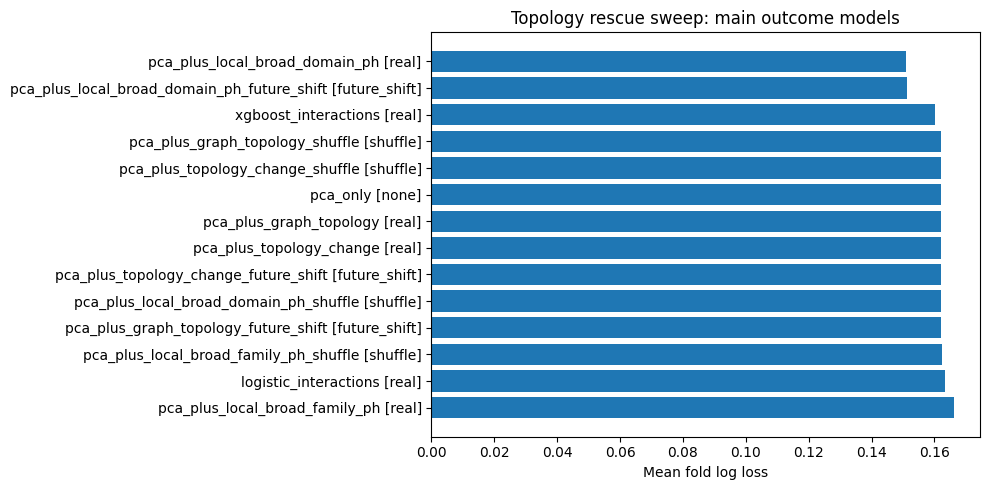

In [5]:
plot_df = main.head(14).sort_values("log_loss", ascending=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(plot_df["model"] + " [" + plot_df["placebo_type"] + "]", plot_df["log_loss"])
ax.set_xlabel("Mean fold log loss")
ax.set_title("Topology rescue sweep: main outcome models")
ax.invert_yaxis()
plt.tight_layout()

## Fold-Level Deltas vs PCA

In [6]:
pca = results[(results["target"].eq("Y_i")) & (results["model"].eq("pca_only"))][["fold", "log_loss", "brier"]].rename(columns={"log_loss": "pca_log_loss", "brier": "pca_brier"})
deltas = results[results["target"].eq("Y_i")].merge(pca, on="fold", how="left")
deltas["delta_log_loss_vs_pca"] = deltas["log_loss"] - deltas["pca_log_loss"]
deltas["delta_brier_vs_pca"] = deltas["brier"] - deltas["pca_brier"]
deltas.sort_values("delta_log_loss_vs_pca").head(20)

,hypothesis,target,task,fold,model,feature_set,placebo_type,n_obs,metric_primary,brier,log_loss,mse,mae,auc,pca_log_loss,pca_brier,delta_log_loss_vs_pca,delta_brier_vs_pca
229,H1_local_topology,Y_i,classification,15,pca_plus_local_broad_domain_ph,local_broad_domain,real,11427,0.079447,0.020583,0.079447,NaN,NaN,0.993283,0.168704,0.046095,-0.089257,-0.025512
231,H1_local_topology,Y_i,classification,15,pca_plus_local_broad_domain_ph_future_shift,local_broad_domain,future_shift,11427,0.083586,0.022255,0.083586,NaN,NaN,0.992313,0.168704,0.046095,-0.085118,-0.023841
213,H1_local_topology,Y_i,classification,14,pca_plus_local_broad_domain_ph,local_broad_domain,real,11444,0.107073,0.032872,0.107073,NaN,NaN,0.987128,0.182226,0.053588,-0.075152,-0.020715
215,H1_local_topology,Y_i,classification,14,pca_plus_local_broad_domain_ph_future_shift,local_broad_domain,future_shift,11444,0.113379,0.035223,0.113379,NaN,NaN,0.985468,0.182226,0.053588,-0.068847,-0.018365
71,H1_local_topology,Y_i,classification,5,pca_plus_local_broad_domain_ph_future_shift,local_broad_domain,future_shift,20281,0.096029,0.023761,0.096029,NaN,NaN,0.961001,0.143797,0.040438,-0.047768,-0.016677
69,H1_local_topology,Y_i,classification,5,pca_plus_local_broad_domain_ph,local_broad_domain,real,20281,0.100351,0.025635,0.100351,NaN,NaN,0.960864,0.143797,0.040438,-0.043446,-0.014803
159,H5_interactions,Y_i,classification,10,xgboost_interactions,topology_interactions,real,20926,0.125662,0.040610,0.125662,NaN,NaN,0.965533,0.161463,0.046045,-0.035801,-0.005435
143,H5_interactions,Y_i,classification,9,xgboost_interactions,topology_interactions,real,21514,0.141711,0.042498,0.141711,NaN,NaN,0.946998,0.171384,0.047313,-0.029673,-0.004814
85,H1_local_topology,Y_i,classification,6,pca_plus_local_broad_domain_ph,local_broad_domain,real,20832,0.082664,0.021333,0.082664,NaN,NaN,0.980689,0.107650,0.026750,-0.024986,-0.005417
87,H1_local_topology,Y_i,classification,6,pca_plus_local_broad_domain_ph_future_shift,local_broad_domain,future_shift,20832,0.083052,0.021297,0.083052,NaN,NaN,0.979769,0.107650,0.026750,-0.024598,-0.005453


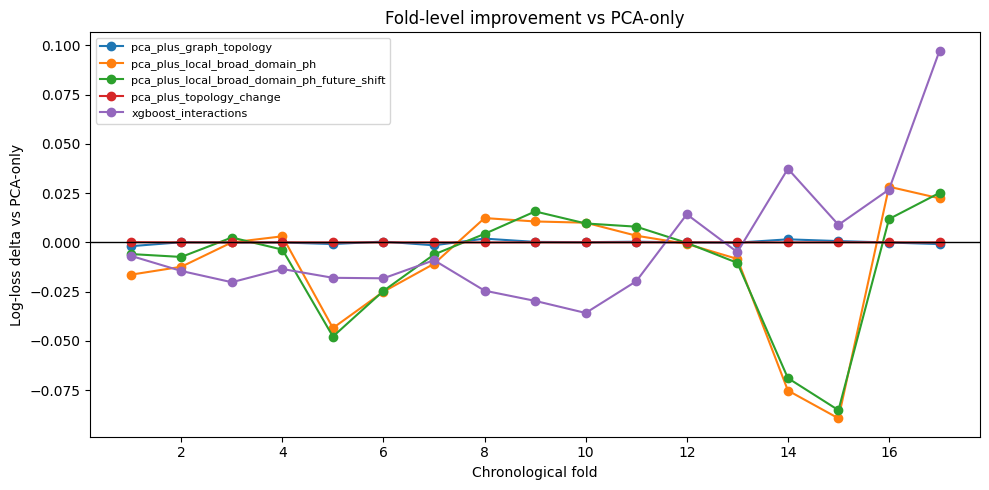

In [7]:
models_to_plot = ["pca_plus_local_broad_domain_ph", "pca_plus_local_broad_domain_ph_future_shift", "xgboost_interactions", "pca_plus_graph_topology", "pca_plus_topology_change"]
fold_plot = deltas[deltas["model"].isin(models_to_plot)]
fig, ax = plt.subplots(figsize=(10, 5))
for model, group in fold_plot.groupby("model"):
    ax.plot(group["fold"], group["delta_log_loss_vs_pca"], marker="o", label=model)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Chronological fold")
ax.set_ylabel("Log-loss delta vs PCA-only")
ax.set_title("Fold-level improvement vs PCA-only")
ax.legend(fontsize=8)
plt.tight_layout()

## Best Results by Hypothesis

In [8]:
summary = (
    results.groupby(["hypothesis", "target", "task", "model", "feature_set", "placebo_type"], as_index=False)
    .agg(folds=("fold", "nunique"), n_obs=("n_obs", "sum"), metric_primary=("metric_primary", "mean"), brier=("brier", "mean"), log_loss=("log_loss", "mean"), mse=("mse", "mean"), mae=("mae", "mean"))
)
best_by_hypothesis = (
    summary[~summary["feature_set"].isin(["pca", "market_probability"])]
    .sort_values("metric_primary")
    .groupby("hypothesis", as_index=False)
    .head(1)
    .sort_values("hypothesis")
)
best_by_hypothesis

,hypothesis,target,task,model,feature_set,placebo_type,folds,n_obs,metric_primary,brier,log_loss,mse,mae
0,H1_local_topology,Y_i,classification,pca_plus_local_broad_domain_ph,local_broad_domain,real,17,282976,0.150809,0.040443,0.150809,NaN,NaN
8,H2_graph_topology,Y_i,classification,pca_plus_graph_topology_shuffle,graph_topology,shuffle,17,282976,0.162062,0.044362,0.162062,NaN,NaN
10,H3_regime_volatility,abs_move_24h,regression,pca_plus_topology_abs_move_24h,residual_topology,real,17,280912,0.000487,NaN,NaN,0.000487,0.009974
19,H4_topology_change,Y_i,classification,pca_plus_topology_change_shuffle,topology_change,shuffle,17,282976,0.162075,0.044368,0.162075,NaN,NaN
21,H5_interactions,Y_i,classification,xgboost_interactions,topology_interactions,real,17,282976,0.160297,0.044265,0.160297,NaN,NaN
25,H6_uncertainty_signal,market_squared_error,regression,pca_plus_topology_error_market_squared_error,residual_topology,real,17,282976,0.018482,NaN,NaN,0.018482,0.056394


## Interpretation

The rescue sweep does not resurrect global raw-trajectory topology. The best primary-outcome signal comes from local broad-domain topology attached to the matching market domain. It improves over PCA-only on aggregate, but the future-shift placebo is close enough that this should be treated as a promising lead requiring stricter validation rather than a final paper claim.